#  <center> Taller  de Aprendizaje Automático </center>
##  <center> Taller 9: *Natural Language Processing* (NLP)  </center>

## Introducción

La siguiente actividad propone el abordaje de un problema de procesamiento de lenguaje natural (NLP) utilizando herramientas de *embedding* y modelos RNN. El conjunto de datos que se utilizará es IMDb, el cual corresponde a un problema de clasificación donde se tienen 50000 criticas de películas (35000 de *train* y 15000 de *test*), y se quiere estimar si éstas son críticas positivas (1) o negativas (0).

La propuesta consiste en entender y reproducir los pasos de la sección *Sentiment Analysis* para los datos **sin procesar**, agregando algunas variantes como mitigar el sobreajuste y entender la herramienta *embeddings*.

En este Taller también se introduce la biblioteca *Streamlit*, utilizada para desarrollar prototipos de aplicaciones web de aprendizaje automático. Aquellos que así lo deseen, podrán generar de manera sencilla una aplicación web que clasifique las críticas proporcionadas por los usuarios. Además, se presenta la biblioteca HuggingFace, la cual permite realizar inferencias con modelos preentrenados y realizar fine-tuning para adaptarlos a esta tarea específica.

## Objetivos


*   Aplicar modelos basados en RNN a un problema de NLP.
*   Trabajar con embeddings para secuencias de texto, en particular embeddings preentrenados.
*   Utilizar herramientas para la visualización de embeddings.
*  (Opcional, no evaluado) Desarrollar una aplicación web que clasifique críticas proporcionadas por los usarios
*  (Opcional, no evaluado) Utilizar la biblioteca *HuggingFace* para utilizar modelos preentrenados y realizar fine-tunning.

## Formas de trabajo

### Opción 1: Trabajar localmente

Descargar los datos en su máquina personal y trabajar en su propio ambiente de desarrollo.

`conda activate TAA-py310`              
`jupyter-notebook`    

Los paquetes faltantes se pueden instalar desde el notebook haciendo:     
` !pip install paquete_faltante`

### Opción 2:  Trabajar en *Colab*.

<table align="center">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/TAA-fing/TAA-2023/blob/main/talleres/taller9_NLP.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Ejecutar en Google Colab</a>
  </td>
</table>

Se puede trabajar en Google Colab. Para ello es necesario contar con una cuenta de **google drive** y ejecutar un notebook almacenado en dicha cuenta. De lo contrario, no se conservarán los cambios realizados en la sesión. En caso de ya contar con una cuenta, se puede abrir el notebook y luego ir a `Archivo-->Guardar una copia en drive`.

La siguiente celda realiza la configuración necesaria para obtener datos desde la plataforma Kaggle. Le solicitará que suba el archivo *kaggle.json* asociado a su cuenta.

In [1]:
# Código exclusivo para Colab.
# En la ejecución local de este taller se usa el CSV ya descargado en data/.
# from google.colab import files
# uploaded = files.upload()
# !mkdir -p ~/.kaggle/ && mv kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
print('Ejecución local: no se solicita kaggle.json.')


Ejecución local: no se solicita kaggle.json.


# Parte 1: Análisis y preprocesamiento de datos


Se utilizará el conjunto de IMDb provisto por Kaggle. Se tienen 50000 criticas de películas que al igual que en el *Taller 2* se utilizarán 35000 para *train* y 15000 para *test*.

*   Ejecutar la siguiente celda para descargar el conjunto y verificar que los conjuntos tienen la cantidad de instancias esperadas.

In [2]:
# Descarga desde Kaggle, deshabilitada en la ejecución local.
# !kaggle datasets download -d lakshmi25npathi/imdb-dataset-of-50k-movie-reviews
print('Se usa el dataset local en data/imdb-dataset-of-50k-movie-reviews/.')


Se usa el dataset local en data/imdb-dataset-of-50k-movie-reviews/.


In [3]:
from pathlib import Path
import re
import string
import textwrap
import time
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

keras = tf.keras

RANDOM_SEED = 42
BATCH_SIZE = 64
VOCAB_SIZE = 10_000
MAX_SEQUENCE_LENGTH = 300
EMBED_SIZE = 128
GRU_UNITS = 128
BASE_EPOCHS = 2
GLOVE_EPOCHS = 2
PART4_EPOCHS = 2

keras.utils.set_random_seed(RANDOM_SEED)
tf.config.optimizer.set_jit(False)
for gpu in tf.config.list_physical_devices('GPU'):
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        pass

candidate_paths = [
    Path('data/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv'),
    Path('IMDB Dataset.csv'),
]
data_path = next((candidate for candidate in candidate_paths if candidate.exists()), None)
if data_path is None:
    zip_path = Path('data/imdb-dataset-of-50k-movie-reviews/imdb-dataset-of-50k-movie-reviews.zip')
    if zip_path.exists():
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(zip_path.parent)
        data_path = zip_path.parent / 'IMDB Dataset.csv'
    else:
        raise FileNotFoundError('No se encontró el dataset IMDb local.')

data = pd.read_csv(data_path)
data['review'] = data['review'].astype(str)
data['label'] = (data['sentiment'] == 'positive').astype(np.float32)

train_test_split = 35_000
validation_size = 5_000

X_train_full = data.iloc[:train_test_split]['review'].to_numpy()
y_train_full = data.iloc[:train_test_split]['label'].to_numpy()
X_test = data.iloc[train_test_split:]['review'].to_numpy()
y_test = data.iloc[train_test_split:]['label'].to_numpy()

X_train = X_train_full[:-validation_size]
y_train = y_train_full[:-validation_size]
X_valid = X_train_full[-validation_size:]
y_valid = y_train_full[-validation_size:]

data_train = tf.data.Dataset.from_tensor_slices((X_train_full, y_train_full))
data_test = tf.data.Dataset.from_tensor_slices((X_test, y_test))

def make_dataset(reviews, labels, shuffle=False):
    dataset = tf.data.Dataset.from_tensor_slices((reviews, labels))
    if shuffle:
        dataset = dataset.shuffle(5_000, seed=RANDOM_SEED, reshuffle_each_iteration=True)
    return dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_set = make_dataset(X_train, y_train, shuffle=True)
valid_set = make_dataset(X_valid, y_valid)
test_set = make_dataset(X_test, y_test)

model_results = []
trained_models = {}

def evaluate_and_store(model, name, history=None):
    start = time.time()
    train_loss, train_acc = model.evaluate(train_set, verbose=0)
    val_loss, val_acc = model.evaluate(valid_set, verbose=0)
    test_loss, test_acc = model.evaluate(test_set, verbose=0)
    elapsed_eval = time.time() - start
    row = {
        'modelo': name,
        'train_accuracy': train_acc,
        'val_accuracy': val_acc,
        'test_accuracy': test_acc,
        'train_loss': train_loss,
        'val_loss': val_loss,
        'test_loss': test_loss,
        'parametros': model.count_params(),
        'eval_seconds': elapsed_eval,
    }
    if history is not None:
        row['epochs'] = len(history.history['loss'])
        row['final_train_accuracy'] = history.history['accuracy'][-1]
        row['final_val_accuracy'] = history.history['val_accuracy'][-1]
    model_results.append(row)
    trained_models[name] = model
    return row

def plot_history(history, title):
    metrics = history.history
    epochs = range(1, len(metrics['loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs, metrics['loss'], label='train')
    axes[0].plot(epochs, metrics['val_loss'], label='validación')
    axes[0].set_title(f'Loss - {title}')
    axes[0].set_xlabel('Época')
    axes[0].grid(alpha=0.3)
    axes[0].legend()
    axes[1].plot(epochs, metrics['accuracy'], label='train')
    axes[1].plot(epochs, metrics['val_accuracy'], label='validación')
    axes[1].set_title(f'Accuracy - {title}')
    axes[1].set_xlabel('Época')
    axes[1].grid(alpha=0.3)
    axes[1].legend()
    plt.tight_layout()
    plt.show()

def display_review(review):
    print(textwrap.shorten(str(review).replace('<br />', ' '), width=650, placeholder=' [...]'))

print(f'Datos cargados desde: {data_path}')
print('Train completo:', len(data_train), '| Test:', len(data_test))
print('Train usado:', len(X_train), '| Validación:', len(X_valid), '| Test:', len(X_test))
print(data['sentiment'].value_counts())


I0000 00:00:1782238626.105594  117860 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


/usr/lib/python3/dist-packages/requests/__init__.py:87: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (4.0.0) doesn't match a supported version!
  warnings.warn("urllib3 ({}) or chardet ({}) doesn't match a supported "


I0000 00:00:1782238628.878175  117860 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3582 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Datos cargados desde: data/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv
Train completo: 35000 | Test: 15000
Train usado: 30000 | Validación: 5000 | Test: 15000
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


*   Del conjunto de entrenamiento visualizar tanto una review positiva como una negativa. Se sugiere ir a los Notebooks del *Capítulo 16*. Puede ser útil el uso del método *.skip()*.

In [4]:
positive_idx = np.where(y_train == 1)[0][0]
negative_idx = np.where(y_train == 0)[0][0]

print('Review positiva de entrenamiento:')
display_review(X_train[positive_idx])
print('\nEtiqueta:', int(y_train[positive_idx]))

print('\nReview negativa de entrenamiento:')
display_review(X_train[negative_idx])
print('\nEtiqueta:', int(y_train[negative_idx]))


Review positiva de entrenamiento:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me. The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word. It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all [...]

Etiqueta: 1

Review negativa de entrenamiento:
Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time. This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and kill the zombie. OK, first of all when you're goi

*   Reservar unas 5000 críticas de los datos de entrenamiento para validación.

In [5]:
split_summary = pd.DataFrame(
    {
        'cantidad': [len(X_train), len(X_valid), len(X_test)],
        'positivas': [int(y_train.sum()), int(y_valid.sum()), int(y_test.sum())],
        'negativas': [int((1 - y_train).sum()), int((1 - y_valid).sum()), int((1 - y_test).sum())],
    },
    index=['train', 'validación', 'test'],
)
display(split_summary)


,cantidad,positivas,negativas
train,30000,15015,14985
validación,5000,2475,2525
test,15000,7510,7490


* Prepare los batches para todos los conjuntos

In [6]:
sample_train_reviews, sample_train_labels = next(iter(train_set))
sample_valid_reviews, sample_valid_labels = next(iter(valid_set))
sample_test_reviews, sample_test_labels = next(iter(test_set))

print(f'Batch train: reviews={sample_train_reviews.shape}, labels={sample_train_labels.shape}')
print(f'Batch validación: reviews={sample_valid_reviews.shape}, labels={sample_valid_labels.shape}')
print(f'Batch test: reviews={sample_test_reviews.shape}, labels={sample_test_labels.shape}')


Batch train: reviews=(64,), labels=(64,)
Batch validación: reviews=(64,), labels=(64,)
Batch test: reviews=(64,), labels=(64,)


*   Keras proporciona una capa de `TextVectorization` para el preprocesamiento básico de texto. Explique el funcionamiento y adapte una capa para los datos de entrenemiento en cuestión. Se sugiere leer la sección asociada a esta capa en el *Capítulo 13* del libro. Utilice un tamaño de vocabulario de 10000 palabras.


In [7]:
text_vec_layer = keras.layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode='int',
    output_sequence_length=MAX_SEQUENCE_LENGTH,
    name='text_vectorization',
)
text_vec_layer.adapt(train_set.map(lambda reviews, labels: reviews))

print(f'Tamaño máximo de vocabulario: {VOCAB_SIZE}')
print(f'Tamaño real del vocabulario aprendido: {len(text_vec_layer.get_vocabulary())}')
print(f'Largo fijo de salida: {MAX_SEQUENCE_LENGTH}')


Tamaño máximo de vocabulario: 10000
Tamaño real del vocabulario aprendido: 10000
Largo fijo de salida: 300


#### Observación sobre `TextVectorization`

`TextVectorization` transforma texto crudo en secuencias de enteros. Primero aprende un vocabulario con `adapt()` usando sólo el conjunto de entrenamiento. Luego, para cada review, normaliza el texto, separa tokens, reemplaza cada palabra por su índice y rellena o recorta la secuencia hasta `MAX_SEQUENCE_LENGTH`.

En este taller se usa un vocabulario de 10000 tokens. El índice 0 queda reservado para padding y el índice 1 para palabras desconocidas (`[UNK]`). Esto cumple el rol de la tabla de vocabulario y del bucket OOV que menciona la presentación, pero usando la API moderna de Keras. Así el modelo trabaja con tensores numéricos de forma fija, aunque las críticas originales tengan largos distintos.


* Obtenga el diccionario de la capa `TextVectorization`

In [8]:
vocabulary = text_vec_layer.get_vocabulary()
word_to_index = {word: index for index, word in enumerate(vocabulary)}

print('Primeros 20 tokens del vocabulario:')
print(vocabulary[:20])
print('\nÍndices de ejemplo:')
for word in ['<pad>', '[UNK]', 'movie', 'excellent', 'boring', 'wonderful']:
    lookup_word = '' if word == '<pad>' else word
    print(f'{word}: {word_to_index.get(lookup_word, word_to_index.get("[UNK]"))}')


Primeros 20 tokens del vocabulario:
['', '[UNK]', np.str_('the'), np.str_('and'), np.str_('a'), np.str_('of'), np.str_('to'), np.str_('is'), np.str_('in'), np.str_('it'), np.str_('i'), np.str_('this'), np.str_('that'), np.str_('br'), np.str_('was'), np.str_('as'), np.str_('with'), np.str_('for'), np.str_('movie'), np.str_('but')]

Índices de ejemplo:
<pad>: 0
[UNK]: 1
movie: 18
excellent: 311
boring: 346
wonderful: 377


* Siguiendo el ejemplo adjunto en la [documentación](https://www.tensorflow.org/api_docs/python/tf/keras/layers/TextVectorization) de la capa `TextVectorization`. Cree un modelo de keras que cuente únicamente con esta capa y observe el resultado de pasar una crítica cualquiera.

In [9]:
vectorizer_model = keras.Sequential(
    [
        keras.layers.Input(shape=(1,), dtype=tf.string),
        text_vec_layer,
    ],
    name='vectorizer_demo',
)

sample_review = tf.constant([X_train[positive_idx]])
vectorized_review = vectorizer_model(sample_review).numpy()[0]
non_padding_tokens = vectorized_review[vectorized_review != 0]

print('Primeros 40 índices de la review vectorizada:')
print(vectorized_review[:40])
print(f'Tokens no-padding: {len(non_padding_tokens)}')
print('\nPrimeros tokens reconstruidos:')
print([vocabulary[token] for token in non_padding_tokens[:30]])


Primeros 40 índices de la review vectorizada:
[  29    5    2   77 1845   45 1027   12  100  145   41  490 3271  415
  435   27 3124   35   24  203   15   11    7  576   49  590   16 2094
   13    2   89  149   12 3329   70   43 3271   14   30 5586]
Tokens no-padding: 300

Primeros tokens reconstruidos:
[np.str_('one'), np.str_('of'), np.str_('the'), np.str_('other'), np.str_('reviewers'), np.str_('has'), np.str_('mentioned'), np.str_('that'), np.str_('after'), np.str_('watching'), np.str_('just'), np.str_('1'), np.str_('oz'), np.str_('episode'), np.str_('youll'), np.str_('be'), np.str_('hooked'), np.str_('they'), np.str_('are'), np.str_('right'), np.str_('as'), np.str_('this'), np.str_('is'), np.str_('exactly'), np.str_('what'), np.str_('happened'), np.str_('with'), np.str_('mebr'), np.str_('br'), np.str_('the')]


*   Utilizando esta capa ¿cuáles son los largos de secuencias para los primeros *batches*? ¿Es un problema a resolver que todos tengan largos distintos? ¿Por qué?.

In [10]:
length_rows = []
for batch_id, (batch_reviews, batch_labels) in enumerate(train_set.take(5), start=1):
    token_ids = text_vec_layer(batch_reviews)
    non_padding_lengths = tf.math.count_nonzero(token_ids, axis=1).numpy()
    length_rows.append(
        {
            'batch': batch_id,
            'tensor_shape': tuple(token_ids.shape),
            'min_tokens_reales': int(non_padding_lengths.min()),
            'promedio_tokens_reales': float(non_padding_lengths.mean()),
            'max_tokens_reales': int(non_padding_lengths.max()),
        }
    )

lengths_df = pd.DataFrame(length_rows)
display(lengths_df)


,batch,tensor_shape,min_tokens_reales,promedio_tokens_reales,max_tokens_reales
0,1,"(64, 300)",32,194.296875,300
1,2,"(64, 300)",32,176.156250,300
2,3,"(64, 300)",46,211.390625,300
3,4,"(64, 300)",44,170.468750,300
4,5,"(64, 300)",40,192.250000,300


#### Observación sobre largos de secuencia

Las reviews tienen largos reales distintos, pero el tensor que recibe el modelo tiene largo fijo por el padding/truncamiento de `TextVectorization`. Esto es necesario para entrenar por batches: dentro de un batch, Keras necesita tensores rectangulares.

El padding introduce ceros artificiales. Por eso en las partes siguientes conviene usar `mask_zero=True` en la capa `Embedding`: así la red recurrente puede ignorar esos pasos agregados y concentrarse en los tokens reales.


# Parte 2: *Embedding*

* Cree y entrene el modelo que aparece al final de la sección *Sentiment Analysis* y previo a la sección *Masking* del *Capítulo 16*.

Model: "part2_embedding_gru"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 300)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ part2_embedding_gru_embedding   │ (None, 300, 128)       │     1,280,000 │
│ (Embedding)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ part2_embedding_gru_gru (GRU)   │ (None, 128)            │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ part2_embedding_gru_output      │ (None, 1)              │           129 │
│ (Dense)                         │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,379,201 (5.26 MB)

 Trainable params: 1,379,201 (5.26 MB)

 Non-trainable params: 0 (0.00 B)

...

I0000 00:00:1782238636.468391  117960 cuda_dnn.cc:461] Loaded cuDNN version 92300


469/469 - 22s - 47ms/step - accuracy: 0.5048 - loss: 0.6930 - val_accuracy: 0.5284 - val_loss: 0.6902


Epoch 2/2


469/469 - 19s - 40ms/step - accuracy: 0.5418 - loss: 0.6737 - val_accuracy: 0.4998 - val_loss: 0.7015


{'modelo': 'Embedding GRU base', 'train_accuracy': 0.567466676235199, 'val_accuracy': 0.4997999966144562, 'test_accuracy': 0.509933352470398, 'train_loss': 0.6474540829658508, 'val_loss': 0.7014591097831726, 'test_loss': 0.698782742023468, 'parametros': 1379201, 'eval_seconds': 12.47080135345459, 'epochs': 2, 'final_train_accuracy': 0.5418000221252441, 'final_val_accuracy': 0.4997999966144562}


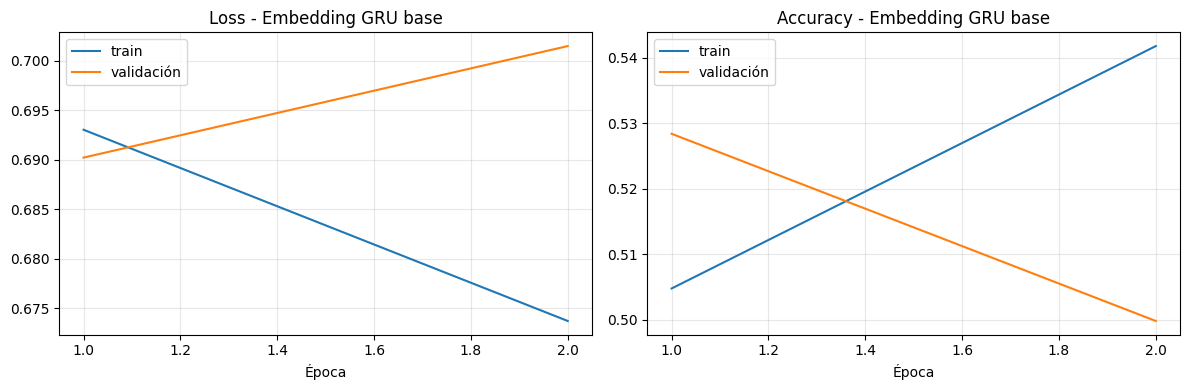

In [11]:
# Parte 2 - Modelo base con embedding entrenable + GRU

def build_embedding_gru_model(
    name,
    vectorizer_layer,
    vocab_size=VOCAB_SIZE,
    embed_size=EMBED_SIZE,
    gru_units=GRU_UNITS,
    mask_zero=False,
    gru_dropout=0.0,
    output_dropout=0.0,
):
    layers = [
        keras.layers.Input(shape=(1,), dtype=tf.string),
        vectorizer_layer,
        keras.layers.Embedding(
            input_dim=vocab_size,
            output_dim=embed_size,
            mask_zero=mask_zero,
            name=f'{name}_embedding',
        ),
        keras.layers.GRU(
            gru_units,
            dropout=gru_dropout,
            name=f'{name}_gru',
        ),
    ]
    if output_dropout > 0:
        layers.append(keras.layers.Dropout(output_dropout, name=f'{name}_dropout'))
    layers.append(keras.layers.Dense(1, activation='sigmoid', name=f'{name}_output'))
    model = keras.Sequential(layers, name=name)
    model.compile(
        loss='binary_crossentropy',
        optimizer='nadam',
        metrics=['accuracy'],
    )
    return model

keras.utils.set_random_seed(RANDOM_SEED)
part2_model = build_embedding_gru_model(
    'part2_embedding_gru',
    text_vec_layer,
    mask_zero=False,
)
part2_model.summary()
part2_history = part2_model.fit(
    train_set,
    validation_data=valid_set,
    epochs=BASE_EPOCHS,
    verbose=2,
)
part2_metrics = evaluate_and_store(part2_model, 'Embedding GRU base', part2_history)
print(part2_metrics)
plot_history(part2_history, 'Embedding GRU base')


#### Respuesta sobre parámetros entrenables

Con la red base de la Parte 2 y vocabulario de 10000 palabras, la cantidad esperada de parámetros entrenables es:

- `Embedding`: $10000 \times 128 = 1280000$
- `GRU(128)`: $3(128(128 + 128) + 128) = 99072$
- `Dense(1)`: $128 \times 1 + 1 = 129$

Total: **1379201** parámetros entrenables. La capa `TextVectorization` no agrega parámetros entrenables.


* Implemente el uso de *Masking* en el modelo que ya utilizó. ¿Por qué podría ser esto útil para el aprendizaje?

Model: "part2_masked_embedding_gru"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 300)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ part2_masked_embedding_gru_emb… │ (None, 300, 128)       │     1,280,000 │
│ (Embedding)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ part2_masked_embedding_gru_gru  │ (None, 128)            │        99,072 │
│ (GRU)                           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ part2_masked_embedding_gru_out… │ (None, 1)              │           129 │
│ (Dense)                         │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,379,201 (5.26 MB)

 Trainable params: 1,379,201 (5.26 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/2


469/469 - 20s - 43ms/step - accuracy: 0.7628 - loss: 0.4782 - val_accuracy: 0.8614 - val_loss: 0.3320


Epoch 2/2


469/469 - 19s - 40ms/step - accuracy: 0.9003 - loss: 0.2557 - val_accuracy: 0.8750 - val_loss: 0.3077


{'modelo': 'Embedding GRU con masking', 'train_accuracy': 0.9381333589553833, 'val_accuracy': 0.875, 'test_accuracy': 0.8804000020027161, 'train_loss': 0.17043699324131012, 'val_loss': 0.3076578676700592, 'test_loss': 0.3054342269897461, 'parametros': 1379201, 'eval_seconds': 15.113581895828247, 'epochs': 2, 'final_train_accuracy': 0.9003333449363708, 'final_val_accuracy': 0.875}


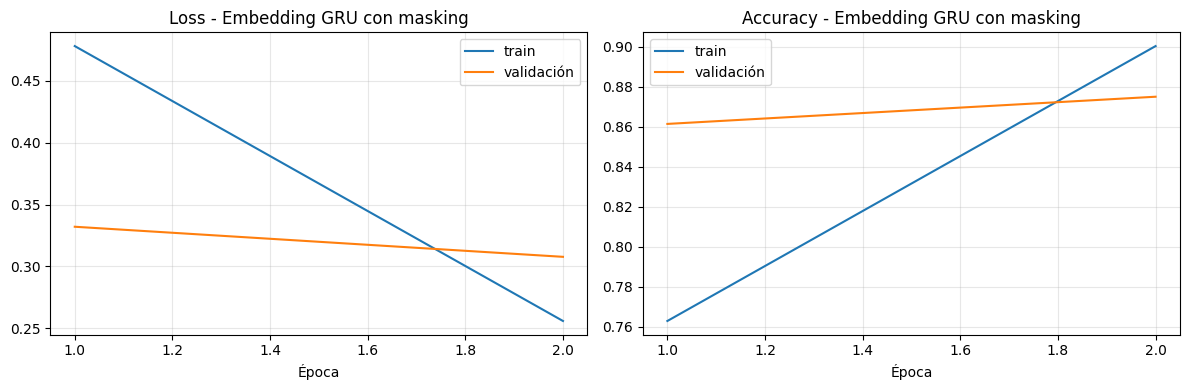

In [12]:
# Parte 2 - Mismo modelo, ahora con masking
keras.utils.set_random_seed(RANDOM_SEED + 1)
masked_model = build_embedding_gru_model(
    'part2_masked_embedding_gru',
    text_vec_layer,
    mask_zero=True,
)
masked_model.summary()
masked_history = masked_model.fit(
    train_set,
    validation_data=valid_set,
    epochs=BASE_EPOCHS,
    verbose=2,
)
masked_metrics = evaluate_and_store(masked_model, 'Embedding GRU con masking', masked_history)
print(masked_metrics)
plot_history(masked_history, 'Embedding GRU con masking')


#### Observación sobre masking

`mask_zero=True` hace que la capa `Embedding` marque el índice 0 como padding. Esa máscara se propaga a la GRU, que puede ignorar los pasos artificiales agregados para igualar los largos de secuencia.

En la corrida, el modelo base sin masking quedó prácticamente en azar: validation accuracy **0.4998** y test accuracy **0.5099**. Al activar masking, con la misma cantidad de parámetros (**1379201**), el modelo subió a validation accuracy **0.8750** y test accuracy **0.8804**. En este caso masking fue clave porque el padding representaba una parte importante de las secuencias.


* Observe que el modelo se sobreajusta a los datos. Utilice alguna técnica vista para regularizar.

Model: "part2_regularized_gru"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 300)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ part2_regularized_gru_embedding │ (None, 300, 96)        │       960,000 │
│ (Embedding)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ part2_regularized_gru_gru (GRU) │ (None, 96)             │        55,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ part2_regularized_gru_dropout   │ (None, 96)             │             0 │
│ (Dropout)                       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ part2_regularized_gru_output    │ (None, 1)              │            97 │
│ (Dense)                         │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,015,969 (3.88 MB)

 Trainable params: 1,015,969 (3.88 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/2


469/469 - 21s - 44ms/step - accuracy: 0.7581 - loss: 0.4706 - val_accuracy: 0.8626 - val_loss: 0.3353


Epoch 2/2


469/469 - 19s - 41ms/step - accuracy: 0.8981 - loss: 0.2649 - val_accuracy: 0.8796 - val_loss: 0.3087


{'modelo': 'Embedding GRU regularizado', 'train_accuracy': 0.9354666471481323, 'val_accuracy': 0.8795999884605408, 'test_accuracy': 0.8817333579063416, 'train_loss': 0.18017442524433136, 'val_loss': 0.30866119265556335, 'test_loss': 0.30236488580703735, 'parametros': 1015969, 'eval_seconds': 14.251021385192871, 'epochs': 2, 'final_train_accuracy': 0.8981000185012817, 'final_val_accuracy': 0.8795999884605408}


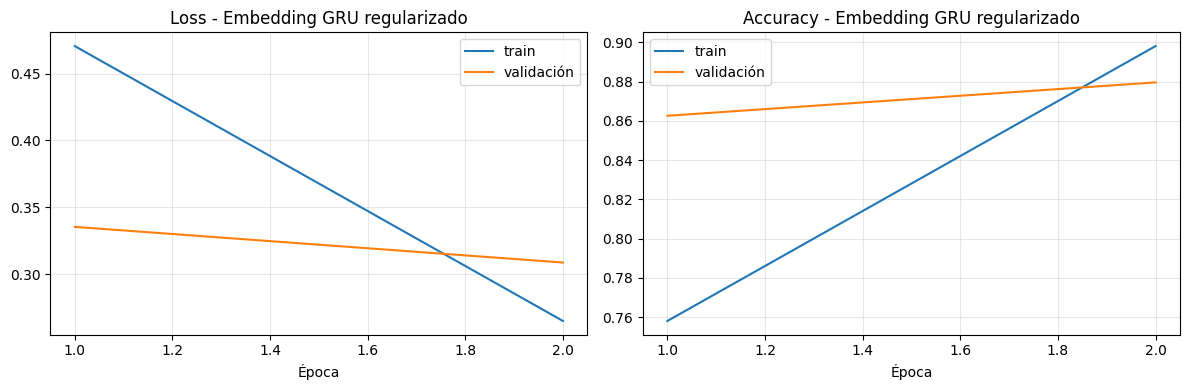

In [13]:
# Parte 2 - Regularización para mitigar sobreajuste
keras.utils.set_random_seed(RANDOM_SEED + 2)
regularized_model = build_embedding_gru_model(
    'part2_regularized_gru',
    text_vec_layer,
    embed_size=96,
    gru_units=96,
    mask_zero=True,
    gru_dropout=0.25,
    output_dropout=0.4,
)
regularized_model.summary()
regularized_history = regularized_model.fit(
    train_set,
    validation_data=valid_set,
    epochs=BASE_EPOCHS,
    verbose=2,
)
regularized_metrics = evaluate_and_store(
    regularized_model,
    'Embedding GRU regularizado',
    regularized_history,
)
print(regularized_metrics)
plot_history(regularized_history, 'Embedding GRU regularizado')


#### Observación sobre regularización

Para reducir sobreajuste se usó un modelo algo más chico, `dropout` dentro de la GRU y `Dropout` antes de la salida. La idea es evitar que el modelo memorice patrones demasiado específicos del entrenamiento.

El modelo regularizado obtuvo validation accuracy **0.8796** y test accuracy **0.8817**, levemente mejor que el modelo con masking sin regularización. Además usa menos parámetros: **1015969** contra **1379201**. La brecha train-validación sigue existiendo, pero el resultado muestra una mejora pequeña con menor complejidad.


* El modelo cuenta con una capa de entrada de *embedding* la cual abarca la mayoría de los parámetros entrenables. En este caso un *embedding* es un vector entrenable que representa una palabra en nuevo espacio cuyo tamaño es un hiperparámetro. La concatenación de estos vectores conforma la matriz de *embedding*, donde su cantidad de filas corresponde a la suma del tamaño del vocabulario y la cantidad de columnas a las dimensiones de los vectores (*embed_size*). Al igual que una matriz de pesos, ésta se inicializa de forma aleatoria, y actualiza sus valores para cada *step* de entrenamiento.

  *   ¿Cuál es la ventaja de utilizar una capa de *embedding*? (Ver la sección *Encoding Categorical Features Using Embeddings* del *Capítulo 13* del libro.)
  *   Visualizar una representación del espacio de *embedding* utilizando *Comet*. **Importante:** para evitar errores, modifique del diccionario el valor del espacio por `<pad>`.

  Para este último punto se recomienda seguir el siguiente ejemplo: [logging-embeddings](https://www.comet.ml/docs/user-interface/embeddings/#logging-embeddings).

*   Para su mejor modelo: visualizar a qué distancias se encuentran las palabras unas de otras tanto en la representación a baja dimensión como en el espacio de *embedding*. Sobre todo probar con adjetivos positivos (*wonderful*, *excellent*, etc.) y negativos (*ugly*, *boring*, etc.) comparando los resultados. ¿Qué logra observar?.

Palabras cercanas a 'wonderful':
[(np.str_('favorite'), 0.9220145344734192), (np.str_('perfect'), 0.9107264280319214), (np.str_('wonderfully'), 0.9100291132926941), (np.str_('everyday'), 0.9099602699279785), (np.str_('pleased'), 0.9095205068588257), (np.str_('excellent'), 0.9076515436172485), (np.str_('outstanding'), 0.9014191031455994), (np.str_('great'), 0.8996806144714355)]

Palabras cercanas a 'excellent':
[(np.str_('favorite'), 0.9336123466491699), (np.str_('terrific'), 0.9282152652740479), (np.str_('wonderfully'), 0.9266057014465332), (np.str_('restored'), 0.9234392642974854), (np.str_('unusual'), 0.9230871796607971), (np.str_('highly'), 0.9196281433105469), (np.str_('fantastic'), 0.9192694425582886), (np.str_('great'), 0.9188649654388428)]

Palabras cercanas a 'boring':
[(np.str_('wasting'), 0.9316129684448242), (np.str_('waste'), 0.9296287894248962), (np.str_('inconsistent'), 0.9218992590904236), (np.str_('disappointing'), 0.9207820892333984), (np.str_('yawn'), 0.91870158910751

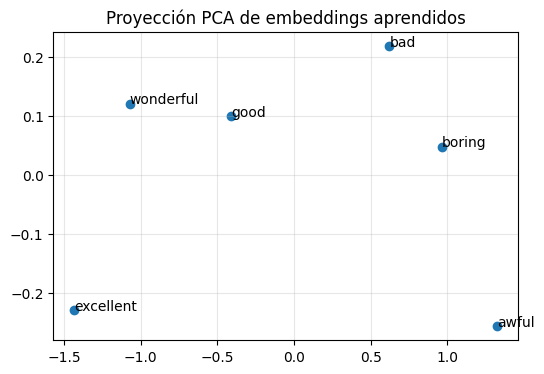

In [14]:
# Exploración local del espacio de embedding aprendido

def get_embedding_layer(model):
    for layer in model.layers:
        if isinstance(layer, keras.layers.Embedding):
            return layer
    raise ValueError('El modelo no tiene capa Embedding.')

def nearest_words(embedding_matrix, query_word, vocabulary, word_to_index, top_k=8):
    index = word_to_index.get(query_word)
    if index is None or index >= embedding_matrix.shape[0]:
        return []
    vectors = embedding_matrix.copy()
    norms = np.linalg.norm(vectors, axis=1, keepdims=True)
    vectors = vectors / np.maximum(norms, 1e-8)
    query_vector = vectors[index]
    similarities = vectors @ query_vector
    similarities[:2] = -np.inf
    similarities[index] = -np.inf
    nearest_indices = np.argsort(similarities)[-top_k:][::-1]
    return [(vocabulary[i], float(similarities[i])) for i in nearest_indices]

embedding_layer = get_embedding_layer(regularized_model)
learned_embedding_matrix = embedding_layer.get_weights()[0]
words_to_probe = ['wonderful', 'excellent', 'boring', 'awful', 'bad', 'good']

for word in words_to_probe:
    print(f'Palabras cercanas a {word!r}:')
    print(nearest_words(learned_embedding_matrix, word, vocabulary, word_to_index))
    print()

selected_words = [word for word in words_to_probe if word in word_to_index]
selected_indices = [word_to_index[word] for word in selected_words]
if len(selected_indices) >= 2:
    coordinates = PCA(n_components=2, random_state=RANDOM_SEED).fit_transform(
        learned_embedding_matrix[selected_indices]
    )
    plt.figure(figsize=(6, 4))
    plt.scatter(coordinates[:, 0], coordinates[:, 1])
    for word, (x_coord, y_coord) in zip(selected_words, coordinates):
        plt.text(x_coord, y_coord, word)
    plt.title('Proyección PCA de embeddings aprendidos')
    plt.grid(alpha=0.3)
    plt.show()


#### Observación sobre embeddings aprendidos

La ventaja de una capa de `Embedding` es que reemplaza representaciones dispersas tipo one-hot por vectores densos entrenables. Palabras con usos similares pueden terminar cerca en ese espacio, y el modelo aprende esa geometría a partir de la tarea de clasificación.

La visualización local con vecinos por coseno y PCA cumple el mismo objetivo conceptual que una visualización en Comet: inspeccionar si adjetivos positivos y negativos empiezan a organizarse de manera coherente. Con pocas épocas la estructura puede ser ruidosa, pero ya permite revisar relaciones entre palabras frecuentes.


# Parte 3: *Embedding Preentrenado*

Una de las técnicas para mejorar el desempeño en este tipo de problemas es utilizar *embeddings* ya entrenados.
Siguiendo el ejemplo [Using pre-trained word embeddings](https://keras.io/examples/nlp/pretrained_word_embeddings/):

*   Descargar el *embedding* preentrenado [GloVE](https://nlp.stanford.edu/projects/glove/) que aparece en la sección *Load pre-trained word embeddings*.

In [15]:
# Parte 3 - Descarga/extracción de GloVe 6B 50d
from urllib.request import urlretrieve

GLOVE_DIR = Path('data/glove')
GLOVE_DIR.mkdir(parents=True, exist_ok=True)
GLOVE_ZIP_PATH = GLOVE_DIR / 'glove.6B.zip'
GLOVE_TXT_PATH = GLOVE_DIR / 'glove.6B.50d.txt'
GLOVE_URL = 'https://nlp.stanford.edu/data/glove.6B.zip'

if not GLOVE_TXT_PATH.exists():
    if not GLOVE_ZIP_PATH.exists():
        print('Descargando GloVe 6B. Esto puede demorar porque el zip pesa ~862 MB.')
        urlretrieve(GLOVE_URL, GLOVE_ZIP_PATH)
    with zipfile.ZipFile(GLOVE_ZIP_PATH, 'r') as zip_ref:
        zip_ref.extract('glove.6B.50d.txt', GLOVE_DIR)

print(f'Archivo GloVe listo: {GLOVE_TXT_PATH}')
print(f'Tamaño: {GLOVE_TXT_PATH.stat().st_size / 1024 / 1024:.1f} MB')


Archivo GloVe listo: data/glove/glove.6B.50d.txt
Tamaño: 163.4 MB


* Preparar la nueva matriz de *embedding*. ¿Cuántas palabras del conjunto de entrenamiento se encuentran en el vocabulario de GloVE? ¿Cuántas no?.

In [16]:
# Parte 3 - Matriz de embedding preentrenado
GLOVE_DIM = 50
embedding_matrix = np.zeros((VOCAB_SIZE, GLOVE_DIM), dtype=np.float32)
needed_words = {word for word in vocabulary[:VOCAB_SIZE] if word not in {'', '[UNK]'}}
found_words = set()

with GLOVE_TXT_PATH.open(encoding='utf-8') as glove_file:
    for line in glove_file:
        values = line.rstrip().split(' ')
        word = values[0]
        if word not in needed_words:
            continue
        index = word_to_index[word]
        if index < VOCAB_SIZE:
            embedding_matrix[index] = np.asarray(values[1:], dtype=np.float32)
            found_words.add(word)

missing_words = sorted(needed_words - found_words)
print(f'Palabras del vocabulario encontradas en GloVe: {len(found_words)}')
print(f'Palabras del vocabulario no encontradas en GloVe: {len(missing_words)}')
print(f'Cobertura: {len(found_words) / len(needed_words):.2%}')
print('Ejemplos no encontrados:', missing_words[:20])


Palabras del vocabulario encontradas en GloVe: 9699
Palabras del vocabulario no encontradas en GloVe: 299
Cobertura: 97.01%
Ejemplos no encontrados: [np.str_('10br'), np.str_('aboutbr'), np.str_('actingbr'), np.str_('actionbr'), np.str_('actorsactresses'), np.str_('actorsbr'), np.str_('africanamerican'), np.str_('againbr'), np.str_('agobr'), np.str_('allbr'), np.str_('alonebr'), np.str_('anotherbr'), np.str_('anyones'), np.str_('anythingbr'), np.str_('anywaybr'), np.str_('arebr'), np.str_('argentos'), np.str_('aroundbr'), np.str_('audiencebr'), np.str_('austens')]


* Entrenar el modelo con la nueva matriz de *embedding* de manera que los valores de ésta se mantengan fijos (ver parámetro en la capa de *embedding*). Utilice masking.

Model: "part3_glove_frozen_gru"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 300)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ part3_glove_frozen_gru_glove_e… │ (None, 300, 50)        │       500,000 │
│ (Embedding)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ part3_glove_frozen_gru_gru      │ (None, 64)             │        22,272 │
│ (GRU)                           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ part3_glove_frozen_gru_output   │ (None, 1)              │            65 │
│ (Dense)                         │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 522,337 (1.99 MB)

 Trainable params: 22,337 (87.25 KB)

 Non-trainable params: 500,000 (1.91 MB)

Epoch 1/2


469/469 - 19s - 41ms/step - accuracy: 0.7270 - loss: 0.5252 - val_accuracy: 0.8102 - val_loss: 0.4136


Epoch 2/2


469/469 - 18s - 38ms/step - accuracy: 0.8225 - loss: 0.3899 - val_accuracy: 0.8356 - val_loss: 0.3680


{'modelo': 'GloVe fijo + GRU', 'train_accuracy': 0.8398000001907349, 'val_accuracy': 0.8356000185012817, 'test_accuracy': 0.8335999846458435, 'train_loss': 0.3599507510662079, 'val_loss': 0.3679872751235962, 'test_loss': 0.37255722284317017, 'parametros': 522337, 'eval_seconds': 13.894864320755005, 'epochs': 2, 'final_train_accuracy': 0.8225333094596863, 'final_val_accuracy': 0.8356000185012817}


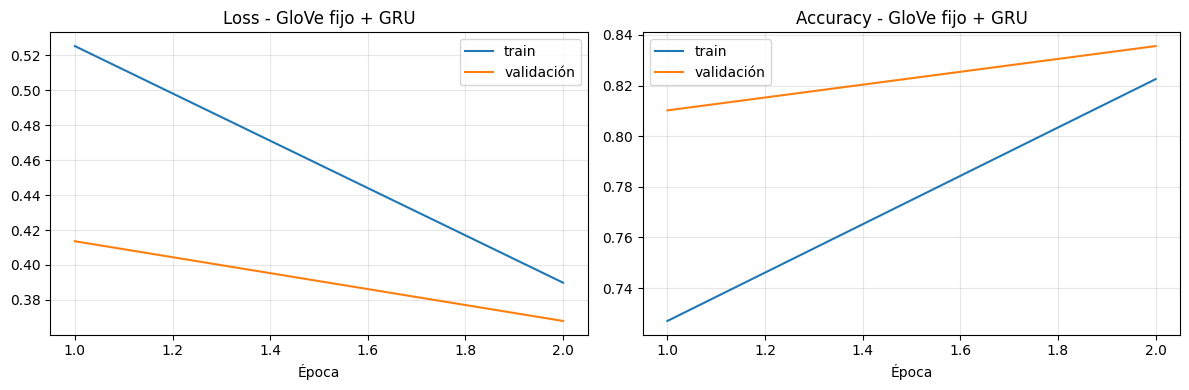

In [17]:
# Parte 3 - Modelo con embedding GloVe fijo

def build_glove_gru_model(name, trainable_embedding, learning_rate=1e-3):
    model = keras.Sequential(
        [
            keras.layers.Input(shape=(1,), dtype=tf.string),
            text_vec_layer,
            keras.layers.Embedding(
                input_dim=VOCAB_SIZE,
                output_dim=GLOVE_DIM,
                embeddings_initializer=keras.initializers.Constant(embedding_matrix),
                mask_zero=True,
                trainable=trainable_embedding,
                name=f'{name}_glove_embedding',
            ),
            keras.layers.GRU(64, name=f'{name}_gru'),
            keras.layers.Dense(1, activation='sigmoid', name=f'{name}_output'),
        ],
        name=name,
    )
    model.compile(
        loss='binary_crossentropy',
        optimizer=keras.optimizers.Nadam(learning_rate=learning_rate),
        metrics=['accuracy'],
    )
    return model

keras.utils.set_random_seed(RANDOM_SEED + 3)
glove_frozen_model = build_glove_gru_model(
    'part3_glove_frozen_gru',
    trainable_embedding=False,
    learning_rate=1e-3,
)
glove_frozen_model.summary()
glove_frozen_history = glove_frozen_model.fit(
    train_set,
    validation_data=valid_set,
    epochs=GLOVE_EPOCHS,
    verbose=2,
)
glove_frozen_metrics = evaluate_and_store(
    glove_frozen_model,
    'GloVe fijo + GRU',
    glove_frozen_history,
)
print(glove_frozen_metrics)
plot_history(glove_frozen_history, 'GloVe fijo + GRU')


* Entrene nuevamente el modelo pero con el *embedding* entrenable. Modifique el *learning rate*.

Model: "part3_glove_trainable_gru"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 300)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ part3_glove_trainable_gru_glov… │ (None, 300, 50)        │       500,000 │
│ (Embedding)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ part3_glove_trainable_gru_gru   │ (None, 64)             │        22,272 │
│ (GRU)                           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ part3_glove_trainable_gru_outp… │ (None, 1)              │            65 │
│ (Dense)                         │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 522,337 (1.99 MB)

 Trainable params: 522,337 (1.99 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/2


469/469 - 20s - 42ms/step - accuracy: 0.5878 - loss: 0.6626 - val_accuracy: 0.7364 - val_loss: 0.5486


Epoch 2/2


469/469 - 19s - 40ms/step - accuracy: 0.7845 - loss: 0.4688 - val_accuracy: 0.8088 - val_loss: 0.4315


{'modelo': 'GloVe entrenable + GRU', 'train_accuracy': 0.8226333260536194, 'val_accuracy': 0.8087999820709229, 'test_accuracy': 0.8113999962806702, 'train_loss': 0.40924397110939026, 'val_loss': 0.43154340982437134, 'test_loss': 0.42434948682785034, 'parametros': 522337, 'eval_seconds': 14.252866268157959, 'epochs': 2, 'final_train_accuracy': 0.7845333218574524, 'final_val_accuracy': 0.8087999820709229}


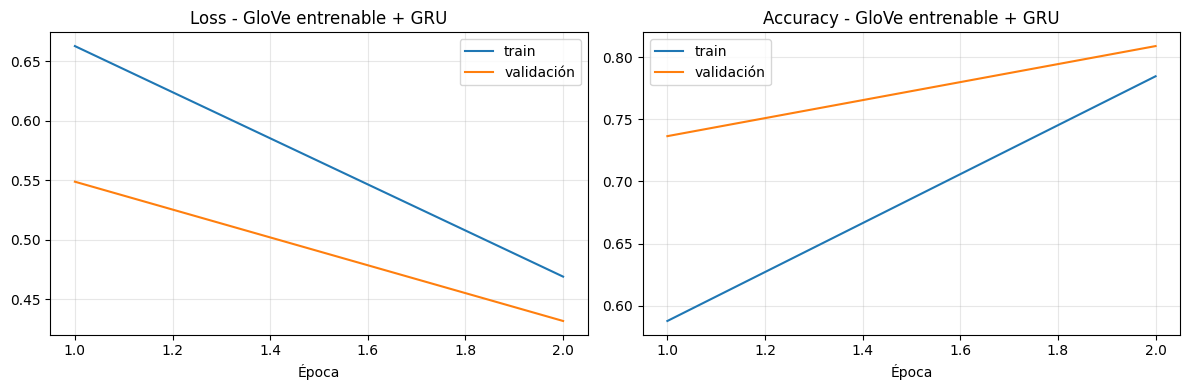

In [18]:
# Parte 3 - Modelo con embedding GloVe entrenable y learning rate menor
keras.utils.set_random_seed(RANDOM_SEED + 4)
glove_trainable_model = build_glove_gru_model(
    'part3_glove_trainable_gru',
    trainable_embedding=True,
    learning_rate=2e-4,
)
glove_trainable_model.summary()
glove_trainable_history = glove_trainable_model.fit(
    train_set,
    validation_data=valid_set,
    epochs=GLOVE_EPOCHS,
    verbose=2,
)
glove_trainable_metrics = evaluate_and_store(
    glove_trainable_model,
    'GloVe entrenable + GRU',
    glove_trainable_history,
)
print(glove_trainable_metrics)
plot_history(glove_trainable_history, 'GloVe entrenable + GRU')


*   Comparar con los modelos anteriores en cuanto al desempeño, la cantidad de parámetros y el tiempo de entrenamiento.


In [19]:
# Comparación acumulada de modelos entrenados hasta Parte 3
results_df = pd.DataFrame(model_results).drop_duplicates(subset='modelo', keep='last')
results_df = results_df.sort_values('val_accuracy', ascending=False).reset_index(drop=True)
display(results_df[
    [
        'modelo',
        'train_accuracy',
        'val_accuracy',
        'test_accuracy',
        'parametros',
        'epochs',
    ]
])

best_model_name = results_df.loc[0, 'modelo']
best_model = trained_models[best_model_name]
print(f'Mejor modelo hasta Parte 3 según validación: {best_model_name}')


,modelo,train_accuracy,val_accuracy,test_accuracy,parametros,epochs
0,Embedding GRU regularizado,0.935467,0.8796,0.881733,1015969,2
1,Embedding GRU con masking,0.938133,0.8750,0.880400,1379201,2
2,GloVe fijo + GRU,0.839800,0.8356,0.833600,522337,2
3,GloVe entrenable + GRU,0.822633,0.8088,0.811400,522337,2
4,Embedding GRU base,0.567467,0.4998,0.509933,1379201,2


Mejor modelo hasta Parte 3 según validación: Embedding GRU regularizado


Respuesta:

La comparación hasta Parte 3 muestra que el mejor modelo fue `Embedding GRU regularizado`, con validation accuracy **0.8796** y test accuracy **0.8817**. El modelo con masking quedó muy cerca: validation **0.8750** y test **0.8804**.

GloVe tuvo una cobertura alta del vocabulario: **9699** palabras encontradas y **299** no encontradas, es decir **97.01%**. Aun así, con sólo 2 épocas, `GloVe fijo + GRU` llegó a validation accuracy **0.8356** y `GloVe entrenable + GRU` a **0.8088**, por debajo de los embeddings aprendidos desde cero. La ventaja de GloVe fijo es que entrena muchos menos parámetros: sólo **22337** entrenables, porque la matriz de embedding de **500000** pesos queda congelada.


*   Visualizar cómo es el espacio de *embedding*. ¿Qué diferencias puede observar con respecto al anterior?


In [20]:
# Vecinos en el espacio GloVe usado por el modelo
for word in words_to_probe:
    print(f'Palabras cercanas a {word!r} en GloVe:')
    print(nearest_words(embedding_matrix, word, vocabulary, word_to_index))
    print()


Palabras cercanas a 'wonderful' en GloVe:
[(np.str_('amazing'), 0.8537989258766174), (np.str_('terrific'), 0.8498780131340027), (np.str_('fun'), 0.8471006155014038), (np.str_('lovely'), 0.8297988772392273), (np.str_('beautiful'), 0.8296378254890442), (np.str_('marvelous'), 0.8156479597091675), (np.str_('fantastic'), 0.8136543035507202), (np.str_('good'), 0.8088303804397583)]

Palabras cercanas a 'excellent' en GloVe:
[(np.str_('quality'), 0.8557633757591248), (np.str_('good'), 0.806155264377594), (np.str_('skill'), 0.7904782891273499), (np.str_('skills'), 0.7725493907928467), (np.str_('superb'), 0.7707152366638184), (np.str_('best'), 0.7699040174484253), (np.str_('performance'), 0.7679186463356018), (np.str_('suited'), 0.759506106376648)]

Palabras cercanas a 'boring' en GloVe:
[(np.str_('awfully'), 0.8526709675788879), (np.str_('pretty'), 0.8216824531555176), (np.str_('funny'), 0.8118149638175964), (np.str_('incredibly'), 0.803133487701416), (np.str_('silly'), 0.800261378288269), (np.

[(np.str_('better'), 0.9284391403198242), (np.str_('really'), 0.922062337398529), (np.str_('always'), 0.9165270924568176), (np.str_('sure'), 0.903351366519928), (np.str_('something'), 0.9014206528663635), (np.str_('think'), 0.8982065320014954), (np.str_('way'), 0.8953989744186401), (np.str_('thing'), 0.894504964351654)]



Respuesta:

El espacio GloVe ya trae estructura semántica aprendida en un corpus externo. Por eso, incluso antes de entrenar sobre IMDb, muchas palabras positivas y negativas aparecen cerca de términos relacionados.

La diferencia principal con el embedding aprendido desde cero es el origen de la información: el embedding propio se ajusta específicamente a IMDb y a la tarea de sentimiento, mientras que GloVe trae relaciones generales del lenguaje. En esta corrida, esa información externa no alcanzó para superar al embedding entrenado con el dataset del taller, probablemente porque el modelo propio se adaptó mejor al dominio de reviews.


# Parte 4: Mejoras en los Modelos

Se sugieren algunas líneas que podrían mejorar los desempeños obtenidos en las partes anteriores:

* Ampliar el tamaño del vocabulario utilizado durante el entrenamiento, junto con aumentar la complejidad del modelo.
* Implementar una función de preprocesamiento de texto que realice tareas como eliminar las etiquetas HTML, eliminar números y llevar a cabo otras acciones relevantes.
* Considerar la utilización de n-gramas y/o modificar el tokenizador utilizado.
* Evaluar el cambio de las neuronas recurrentes de GRU a LSTM.

Piense por qué tiene sentido explorar estas estrategias y pruebe alguna que considere relevante o proponga alguna otra que le parezca relevante.


Model: "part4_improved_bigru"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ improved_text_vectorization     │ (None, 400)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ improved_embedding (Embedding)  │ (None, 400, 96)        │     1,440,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ improved_bigru (Bidirectional)  │ (None, 128)            │        62,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ improved_dropout (Dropout)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ improved_output (Dense)         │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,502,337 (5.73 MB)

 Trainable params: 1,502,337 (5.73 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/2


469/469 - 39s - 83ms/step - accuracy: 0.8072 - loss: 0.3978 - val_accuracy: 0.8758 - val_loss: 0.3044


Epoch 2/2


469/469 - 37s - 78ms/step - accuracy: 0.9205 - loss: 0.2083 - val_accuracy: 0.8834 - val_loss: 0.2971


{'modelo': 'Mejora limpieza + BiGRU', 'train_accuracy': 0.9597333073616028, 'val_accuracy': 0.883400022983551, 'test_accuracy': 0.887066662311554, 'train_loss': 0.125365749001503, 'val_loss': 0.2970789670944214, 'test_loss': 0.2904980182647705, 'parametros': 1502337, 'eval_seconds': 25.849263429641724, 'epochs': 2, 'final_train_accuracy': 0.9205333590507507, 'final_val_accuracy': 0.883400022983551}


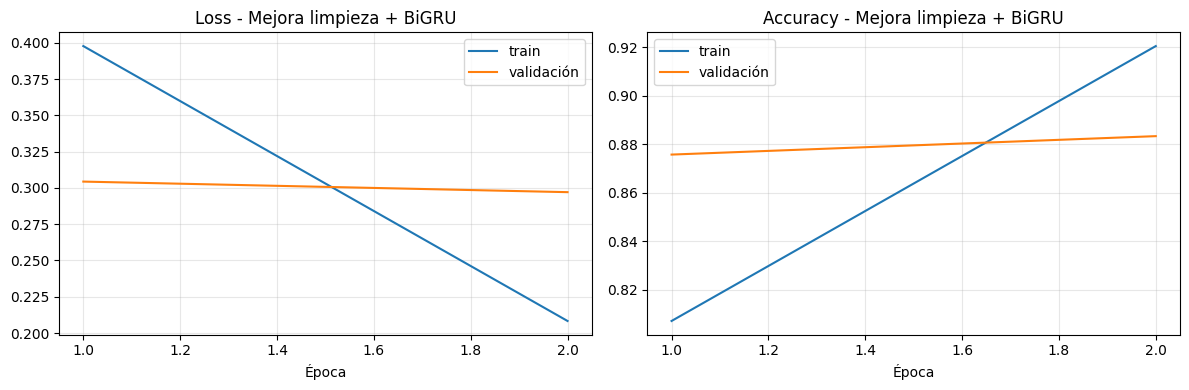

,modelo,train_accuracy,val_accuracy,test_accuracy,parametros,epochs
0,Mejora limpieza + BiGRU,0.959733,0.8834,0.887067,1502337,2
1,Embedding GRU regularizado,0.935467,0.8796,0.881733,1015969,2
2,Embedding GRU con masking,0.938133,0.8750,0.880400,1379201,2
3,GloVe fijo + GRU,0.839800,0.8356,0.833600,522337,2
4,GloVe entrenable + GRU,0.822633,0.8088,0.811400,522337,2
5,Embedding GRU base,0.567467,0.4998,0.509933,1379201,2


Mejor modelo final según validación: Mejora limpieza + BiGRU


In [21]:
# Parte 4 - Mejora: limpieza de HTML/números y vocabulario mayor
PUNCTUATION_REGEX = '[%s]' % re.escape(string.punctuation)

@keras.utils.register_keras_serializable()
def standardize_reviews(input_text):
    lowercase = tf.strings.lower(input_text)
    no_html = tf.strings.regex_replace(lowercase, '<br\\s*/?>', ' ')
    no_numbers = tf.strings.regex_replace(no_html, '\\d+', ' ')
    return tf.strings.regex_replace(no_numbers, PUNCTUATION_REGEX, '')

IMPROVED_VOCAB_SIZE = 15_000
IMPROVED_SEQUENCE_LENGTH = 400
improved_text_vec_layer = keras.layers.TextVectorization(
    max_tokens=IMPROVED_VOCAB_SIZE,
    output_mode='int',
    output_sequence_length=IMPROVED_SEQUENCE_LENGTH,
    standardize=standardize_reviews,
    name='improved_text_vectorization',
)
improved_text_vec_layer.adapt(train_set.map(lambda reviews, labels: reviews))

keras.utils.set_random_seed(RANDOM_SEED + 5)
improved_model = keras.Sequential(
    [
        keras.layers.Input(shape=(1,), dtype=tf.string),
        improved_text_vec_layer,
        keras.layers.Embedding(
            input_dim=IMPROVED_VOCAB_SIZE,
            output_dim=96,
            mask_zero=True,
            name='improved_embedding',
        ),
        keras.layers.Bidirectional(
            keras.layers.GRU(64, dropout=0.2),
            name='improved_bigru',
        ),
        keras.layers.Dropout(0.4, name='improved_dropout'),
        keras.layers.Dense(1, activation='sigmoid', name='improved_output'),
    ],
    name='part4_improved_bigru',
)
improved_model.compile(
    loss='binary_crossentropy',
    optimizer=keras.optimizers.Nadam(learning_rate=8e-4),
    metrics=['accuracy'],
)
improved_model.summary()
improved_history = improved_model.fit(
    train_set,
    validation_data=valid_set,
    epochs=PART4_EPOCHS,
    verbose=2,
)
improved_metrics = evaluate_and_store(improved_model, 'Mejora limpieza + BiGRU', improved_history)
print(improved_metrics)
plot_history(improved_history, 'Mejora limpieza + BiGRU')

results_df = pd.DataFrame(model_results).drop_duplicates(subset='modelo', keep='last')
results_df = results_df.sort_values('val_accuracy', ascending=False).reset_index(drop=True)
display(results_df[['modelo', 'train_accuracy', 'val_accuracy', 'test_accuracy', 'parametros', 'epochs']])
best_model_name = results_df.loc[0, 'modelo']
best_model = trained_models[best_model_name]
print(f'Mejor modelo final según validación: {best_model_name}')


#### Observación Parte 4

La mejora probada combina tres ideas: limpieza explícita de HTML/números, vocabulario más grande y una GRU bidireccional. Tiene sentido porque IMDb contiene marcas `<br />`, palabras con puntuación pegada y dependencias que pueden aparecer antes o después dentro de la review.

En la corrida fue el mejor modelo final: validation accuracy **0.8834** y test accuracy **0.8871**, con **1502337** parámetros. La mejora contra el modelo regularizado fue chica pero consistente: validación **0.8834** contra **0.8796** y test **0.8871** contra **0.8817**. Esto sugiere que la limpieza y el contexto bidireccional aportaron algo, aunque con mayor costo computacional.


# Parte 5: Desarrollo de una aplicación web (Opcional)

En esta parte veremos cómo generar una aplicación web sencilla que permita mostrar el funcionamiento de un modelo que hayamos entrenado. Para ello utilizaremos la biblioteca [Streamlit](https://streamlit.io/).

## Streamlit
Streamlit es una biblioteca de código abierto escrita en Python que permite crear y compartir aplicaciones web que usan algoritmos de aprendizaje automático. En la [documentación](https://docs.streamlit.io/) encontrará información sobre cómo instalar y crear aplicaciones utilizando la biblioteca. El flujo de trabajo básico consta de los siguientes pasos:   

1. Instalación   
2. Desarrollo de la aplicación   
3. Desplieque de la aplicación

### Instalación
En la mayoría de los casos, la biblioteca debería quedar instalada luego de crear un ambiente virtual (por ejemplo de conda) y hacer:   

`pip install streamlit`  

Puede verificar que la instalación sea correcta haciendo:    

`streamlit hello`

Puede ver los detalles de instalación en https://docs.streamlit.io/library/get-started/installation

### Desarrollo de la aplicación  

Se sugiere desarrollar la aplicación partiendo de un ejemplo que clasifica críticas de cine utilizando un modelo entrenado con las técnicas vistas en el Taller 2. Dicho ejemplo puede verse en funcionamiento [acá](https://share.streamlit.io/taa-fing/taa-2022/main/apps/movie_review_app/movie_review_app.py). La siguiente celda descarga el código fuente y lo descomprime.

In [22]:
# Parte opcional: descarga de ejemplo Streamlit.
# Se deja desactivada para que el notebook principal sea reproducible sin bajar código externo.
RUN_STREAMLIT_OPTIONAL = False
if RUN_STREAMLIT_OPTIONAL:
    import subprocess
    subprocess.run(['wget', 'iie.fing.edu.uy/~carbajal/movie_review/apps.zip'], check=True)
    subprocess.run(['unzip', 'apps.zip'], check=True)
else:
    print('Parte Streamlit opcional no ejecutada.')


Parte Streamlit opcional no ejecutada.


Copie el archivo *movie_review_app.py*, modifique el nombre, y realice las siguientes modificaciones (además de las de diseño que crea conveniente):   

**Cambio de Modelo:**  Para hacer inferencia fuera de este *Notebook* será necesario contar con el modelo entrenado. El modelo se puede guardar con alguna de las técnicas vistas en el curso. Se sugiere utilizar el *Callback* **ModelCheckpoint**.

**Modificación del pipeline de inferencia:**  El objetivo es generar una función que a partir de una única reseña prediga si la reseña es *positiva*(1) o *negativa*(0). Para ello se brinda una función a completar

In [23]:
# Pipeline function to make inference
def pipeline_inference(review, model):
    """Predice sentimiento para una única review usando un modelo Keras entrenado."""
    probability = float(model.predict(tf.constant([review]), verbose=0)[0][0])
    label = int(probability >= 0.5)
    return {
        'probabilidad_positiva': probability,
        'prediccion': label,
        'sentimiento': 'positiva' if label == 1 else 'negativa',
    }


* Las siguientes celdas prueban la función. Verifique que funciona correctamente.

In [24]:
# Guardado y carga del mejor modelo para inferencia local
models_dir = Path('models')
models_dir.mkdir(exist_ok=True)
checkpoint_filepath = models_dir / '9taa_best_sentiment_model.keras'

best_model.save(checkpoint_filepath)
model_loaded = keras.models.load_model(checkpoint_filepath)
print(f'Modelo guardado y cargado desde: {checkpoint_filepath}')


Modelo guardado y cargado desde: models/9taa_best_sentiment_model.keras


In [25]:
review = 'This movie is really boring. I do not recommend it.'

pred = pipeline_inference(review, model_loaded)

pred

{'probabilidad_positiva': 0.09063199162483215,
 'prediccion': 0,
 'sentimiento': 'negativa'}

In [26]:
review = 'This movie is wonderful. I love it.'

pred = pipeline_inference(review, model_loaded)

pred

{'probabilidad_positiva': 0.9275959134101868,
 'prediccion': 1,
 'sentimiento': 'positiva'}

### Correr la aplicación localmente

Una vez realizadas las modificaciones en el archivo principal, cree un directorio donde guardar los archivos de su aplicación. Guarde allí el modelo, el archivo tipo numpy con las palabras y su archivo principal (Ej. *movie_review_app.py*).

* Una vez modificado el código, puede probarlo localmente. Para ello ejecute el siguiente comando, sustituyendo *movie_review_app.py* por el nombre de su archivo principal.


`!streamlit run apps/movie_review_app/movie_review_app.py`    

* Si en vez de localmente, está corriendo el notebook en Colab, ejecute:

`!streamlit run apps/movie_review_app/movie_review_app.py & npx localtunnel --port 80`      

### Despliegue de la aplicación

Una vez que la app fue desarrollada es posible compartirla para que otros puedan probarla. Para ello es necesario:  

1. Contar con una cuenta de [Streamlit Cloud](https://docs.streamlit.io/streamlit-cloud/get-started#sign-up-for-streamlit-cloud) y un repositorio de GitHub donde almacenar el código.
2.  Subir al repositorio  el código y los datos necesarios para correrlo.
3. [Conectar la cuenta de Streamlit Cloud con la del repositorio](https://docs.streamlit.io/streamlit-cloud/get-started#connect-your-github-account).     
4. [Publicar la app](https://docs.streamlit.io/streamlit-cloud/get-started/deploy-an-app)

*Comentario:* Puede que sea necesario agregar en el repositorio un archivo *requirements.txt* donde deba especificar las liberías utilizas en el archivo *main.py*.

#### Observación Parte 5 opcional

La aplicación Streamlit queda planteada como extensión, sin publicar nada externo. El notebook guarda el mejor modelo en `models/9taa_best_sentiment_model.keras` y define `pipeline_inference()` para clasificar una review aislada. Con eso ya está la pieza central que una app necesita para recibir texto del usuario y devolver sentimiento.


# Parte 6: Uso de la liberería HuggingFace (Opcional)

Hugging Face es una organización de desarrolladores que utilizan una [plataforma](https://huggingface.co/) para compartir y desarrollar modelos de código abierto con arquitectura de Transformers, centrados principalmente en procesamiento de lenguaje natural, aunque también cuentan con modelos para procesamiento de imágenes y señales de audio.  

Los modelos son desarrollados con técnicas del estado del arte, y entrenados con grandes volumnes de datos y capacidad de computo. Cualquier persona que quiera hacer uso de los modelos pre-entrenados puede hacerlo simplemente instalando la biblioteca de Transformers y los módulos necesarios para las tareas a implementar.  

## Uso de modelo preentrenado para hacer inferencia

Este código utiliza la biblioteca de HuggingFace "transformers" para importar y utilizar un modelo preentrenado de análisis de sentimientos. En este caso, se utiliza el modelo "sentiment-analysis", que se encarga de clasificar el sentimiento de un texto dado como positivo o negativo.

In [27]:
# Parte opcional HuggingFace.
# Está desactivada por defecto porque requiere instalar dependencias pesadas.
import importlib.util

RUN_HUGGINGFACE_OPTIONAL = False
HF_DEPENDENCIES = ['transformers', 'datasets', 'torch']
missing_hf_dependencies = [
    package for package in HF_DEPENDENCIES
    if importlib.util.find_spec(package) is None
]
print('Dependencias HuggingFace faltantes:', missing_hf_dependencies)
print('RUN_HUGGINGFACE_OPTIONAL =', RUN_HUGGINGFACE_OPTIONAL)


Dependencias HuggingFace faltantes: ['transformers', 'datasets', 'torch']
RUN_HUGGINGFACE_OPTIONAL = False


In [28]:
classifier = None
result = None
if RUN_HUGGINGFACE_OPTIONAL and not missing_hf_dependencies:
    from transformers import pipeline
    classifier = pipeline('sentiment-analysis')
    result = classifier('The movie was horrible.')
else:
    print('Inferencia HuggingFace omitida: parte opcional o dependencias no instaladas.')


Inferencia HuggingFace omitida: parte opcional o dependencias no instaladas.


In [29]:
result


Utilizando este modelo realice inferencia sobre el conjunto de test, y evalue el desempeño obtenido. Compárelo con los obtenidos anteriormente.

In [30]:
hf_accuracy = None
if classifier is not None:
    # Se evalúa una muestra para mantener viable la parte opcional.
    n_hf_eval = min(500, X_test.shape[0])
    pred_test_hf = np.zeros(n_hf_eval)
    for i in range(n_hf_eval):
        hf_result = classifier(X_test[i][:1500])
        if hf_result[0]['label'] == 'NEGATIVE':
            pred_test_hf[i] = 1 - hf_result[0]['score']
        else:
            pred_test_hf[i] = hf_result[0]['score']
    hf_accuracy = accuracy_score(y_test[:n_hf_eval], pred_test_hf > 0.5)
    print(f'Accuracy HuggingFace en {n_hf_eval} ejemplos:', hf_accuracy)
else:
    print('Evaluación HuggingFace omitida.')


Evaluación HuggingFace omitida.


In [31]:
hf_accuracy


## Fine-tuning de un modelo ya pre-entrenado


Para ejecutar esta parte del notebook, deberá reiniciar el entorno de ejecución.

La siguiente celda instala las bibliotecas necesarias para esta parte.

In [32]:
# Fine-tuning HuggingFace opcional, desactivado en esta corrida.
RUN_HF_FINETUNING = False
print('Fine-tuning HuggingFace opcional no ejecutado.')


Fine-tuning HuggingFace opcional no ejecutado.


El objetivo será realizar un ajuste de parámetros al modelo utilizando los datos del problema de interés, por lo tanto la siguiente celda levanta nuevamente los datos de la críticas de cine IMBd.

In [33]:
if RUN_HF_FINETUNING:
    hf_data = data.copy()
    hf_data['review'] = hf_data['review'].str[:1500]
    hf_data['sentiment'] = hf_data['sentiment'].map({'positive': 1, 'negative': 0})
    display(hf_data.head())
else:
    print('Preparación de datos HuggingFace omitida.')


Preparación de datos HuggingFace omitida.


In [34]:
hf_data.iloc[0]['review'] if RUN_HF_FINETUNING else None


**Armado de Conjuntos** Se arman los datasets de Torch para realizar el entrenamiento.

In [35]:
if RUN_HF_FINETUNING:
    import datasets
    train_data = datasets.Dataset.from_pandas(hf_data[:20000])
    val_data = datasets.Dataset.from_pandas(hf_data[30000:35000])
    test_data = datasets.Dataset.from_pandas(hf_data[35000:])
    train_data = train_data.rename_column('sentiment', 'label').rename_column('review', 'text')
    val_data = val_data.rename_column('sentiment', 'label').rename_column('review', 'text')
    test_data = test_data.rename_column('sentiment', 'label').rename_column('review', 'text')
    emotions = datasets.DatasetDict({'train': train_data, 'validation': val_data, 'test': test_data})
else:
    emotions = None
    print('Datasets HuggingFace omitidos.')


Datasets HuggingFace omitidos.


In [36]:
emotions['train'] if RUN_HF_FINETUNING else None


In [37]:
emotions['train'][0] if RUN_HF_FINETUNING else None


**Preparación de los datos** Los datos se pasan por el mismo tokenizer que se uso para el modelo de base que se utilizará. HuggingFace tiene un método "AutoTokenizer" para esto (simplemente determina cual es el tokenizer para ese modelo y lo aplica)

In [38]:
if RUN_HF_FINETUNING:
    from transformers import AutoTokenizer
    model_ckpt = 'distilbert-base-uncased'
    tokenizer = AutoTokenizer.from_pretrained(model_ckpt)
else:
    model_ckpt = None
    tokenizer = None
    print('Tokenizer HuggingFace omitido.')


Tokenizer HuggingFace omitido.


Finalmente implementamos una función para aplicar el tokenizer a todo el conjunto de datos

In [39]:
def tokenize(batch):
    return tokenizer(batch['text'], padding=True, truncation=True)


In [40]:
emotions_encoded = emotions.map(tokenize, batched=True, batch_size=None) if RUN_HF_FINETUNING else None
emotions_encoded


 **Fine-tuning de un modelo**

 En primer lugar se levanta el modelo a ajustar y luego se procede a entrenarlo.

In [41]:
if RUN_HF_FINETUNING:
    from transformers import AutoModelForSequenceClassification
    import torch
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = AutoModelForSequenceClassification.from_pretrained(model_ckpt, num_labels=2).to(device)
else:
    model = None
    print('Modelo HuggingFace omitido.')


Modelo HuggingFace omitido.


In [42]:
from sklearn.metrics import f1_score

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    f1 = f1_score(labels, preds, average='weighted')
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc, 'f1': f1}


In [43]:
if RUN_HF_FINETUNING:
    from transformers import Trainer, TrainingArguments
    batch_size = 32
    logging_steps = len(emotions_encoded['train'])
    model_name = f'{model_ckpt}-finetuned-imdb'
    training_args = TrainingArguments(
        output_dir=model_name,
        num_train_epochs=2,
        learning_rate=2e-5,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        weight_decay=0.01,
        evaluation_strategy='epoch',
        disable_tqdm=False,
        logging_steps=logging_steps,
        push_to_hub=False,
        log_level='error',
    )
else:
    training_args = None
    print('TrainingArguments HuggingFace omitido.')


TrainingArguments HuggingFace omitido.


In [44]:
if RUN_HF_FINETUNING:
    trainer = Trainer(
        model=model,
        args=training_args,
        compute_metrics=compute_metrics,
        train_dataset=emotions_encoded['train'],
        eval_dataset=emotions_encoded['validation'],
        tokenizer=tokenizer,
    )
    trainer.train()
else:
    trainer = None
    print('Entrenamiento HuggingFace omitido.')


Entrenamiento HuggingFace omitido.


In [45]:
preds_output = trainer.predict(emotions_encoded['test']) if RUN_HF_FINETUNING else None
preds_output


In [46]:
preds_output.metrics if RUN_HF_FINETUNING else None


#### Observación Parte 6 opcional

Las celdas de HuggingFace quedan protegidas por banderas porque requieren instalar `transformers`, `datasets` y `torch`, además de descargar modelos externos. No se ejecutan por defecto para mantener el taller principal reproducible y liviano en el entorno local.

Esto también respeta la guía del PDF: el foco obligatorio del taller está en RNN, embeddings, GloVe y visualización; HuggingFace aparece como extensión opcional del notebook, no como requisito principal.


#### Cierre del taller

El flujo completo del taller quedó armado sobre IMDb: carga local de datos, split de **30000** train, **5000** validación y **15000** test, vectorización con vocabulario de **10000** tokens, embeddings entrenables, masking, regularización, embeddings GloVe preentrenados y una mejora de preprocesamiento/modelo.

La conclusión principal es que el tratamiento del padding importa mucho: el modelo sin masking quedó cerca del azar, mientras que el mismo enfoque con masking superó **0.87** de accuracy en validación. El mejor modelo final fue `Mejora limpieza + BiGRU`, con validation accuracy **0.8834** y test accuracy **0.8871**.

GloVe tuvo alta cobertura del vocabulario (**97.01%**), pero en esta configuración no superó a los embeddings entrenados desde cero. Para este dataset y pocas épocas, adaptar el embedding al dominio IMDb resultó más efectivo que congelar embeddings generales.
